---
description: "A practical split between within-row features TabPFN can recover and cross-row aggregates it still needs."
---

# Feature engineering

Feature engineering is the lever a gradient-boosting practitioner trusts most: hand-craft the features
that let the model see structure it cannot learn on its own. The question for a pretrained model is
whether that lever still works. The answer is not "no" and not "yes". It splits cleanly along one line:
features computed from a **single row** versus features computed **across rows**.

- **Within-row** (a row's own values): interactions `x1*x2`, ratios `x1/x2`, polynomials, binning.
- **Cross-row** (statistics over many rows): group-by aggregates, count and frequency encodings,
  target encoding, entity aggregates ("this card's average transaction").

That second family is not a new TabPFN idea. It is the old Kaggle feature-engineering playbook: per-client
aggregates in [Home Credit](https://www.kaggle.com/code/willkoehrsen/introduction-to-manual-feature-engineering),
per-value frequency features in [Santander](https://www.kaggle.com/code/cdeotte/200-magical-models-santander-0-920),
and UID or count features in [IEEE-CIS fraud](https://www.kaggle.com/code/cdeotte/xgb-fraud-with-magic-0-9600).
Recent systems such as [AutoGluon](https://arxiv.org/abs/2003.06505) and the June 2026
[TabPrep](https://arxiv.org/abs/2606.02384) paper help name and automate parts of this playbook, but the
intuition comes from practice the reader has probably seen before.

We will see that TabPFN recovers the first family for free and genuinely needs the second, the opposite
of the lazy take that "TabPFN does not need feature engineering." Every experiment is a small synthetic
construction plus one real dataset. Everything here is the local `tabpfn` 8.0.3 package.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
from tqdm import tqdm
from tabulate import tabulate

from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from tabpfn import TabPFNClassifier


def printdf(df, nrows=10, showindex=True):
    """Print a small dataframe as an aligned text table."""
    print(tabulate(df.head(nrows), headers="keys", tablefmt="psql", showindex=showindex))


def sigmoid(z):
    """Convert a log-odds score into a probability."""
    return 1.0 / (1.0 + np.exp(-z))


def standardize(values):
    """Put a vector on mean 0 and standard deviation 1."""
    return (values - values.mean()) / (values.std() + 1e-9)


def score(model_name, X_train, y_train, X_test, y_test, seed=0, cat_cols=()):
    """Fit one model and return test ROC AUC.

    The experiments pass categorical columns in the form each model expects:
    raw values for TabPFN, pandas category dtype for LightGBM, and strings plus
    explicit categorical-column indices for CatBoost.
    """
    train_features = X_train.copy()
    test_features = X_test.copy()

    if model_name == "lightgbm":
        for column in cat_cols:
            train_features[column] = train_features[column].astype("category")
            test_features[column] = pd.Categorical(
                test_features[column],
                categories=train_features[column].cat.categories,
            )
        model = LGBMClassifier(verbose=-1, random_state=seed)

    elif model_name == "catboost":
        for column in cat_cols:
            train_features[column] = train_features[column].astype(str)
            test_features[column] = test_features[column].astype(str)
        categorical_indices = [train_features.columns.get_loc(column) for column in cat_cols]
        model = CatBoostClassifier(
            verbose=0,
            random_state=seed,
            cat_features=categorical_indices or None,
        )

    elif model_name == "logreg":
        model = Pipeline([
            ("scale", StandardScaler()),
            ("lr", LogisticRegression(max_iter=2000)),
        ])

    else:
        model = TabPFNClassifier(random_state=seed)

    model.fit(train_features, y_train)
    probabilities = model.predict_proba(test_features)[:, 1]
    return roc_auc_score(y_test, probabilities)


## Feature-engineering checklist

Start with the checklist a strong Kaggle notebook would use, not with a paper taxonomy.

- **Within-row.** Arithmetic of a row's own columns: `x1*x2`, `x1/x2`, `age*hours`, polynomial terms.
  The classic reason to do it: a linear model cannot form a product, and a shallow tree forms it only
  clumsily, so you hand it the feature directly.
- **Cross-row.** A statistic computed by scanning many rows: the mean of a numeric within a category,
  how often a value occurs (count / frequency), the out-of-fold target mean for a category, the average
  transaction for a card. You cannot compute any of these from one row alone; you need a `groupby`.

AutoGluon and TabPrep use related feature-generator language, but they should be supporting references,
not assumed background. For this chapter, the reader only needs the split above: **inside one row** versus
**across many rows**.


## TabPFN treatment

TabPFN is a transformer. **Within a row** it attends across the features, so it can form products and
interactions internally; a within-row engineered feature mostly recomputes something it already has.
But each prediction attends to the **training rows as context**; it does not pool an entity's other
rows into an aggregate the way a `groupby` does. So a **cross-row** feature is information it cannot
assemble for itself.

That predicts the chapter: within-row FE should be redundant for TabPFN, cross-row FE should help it.
The next three experiments measure exactly that.

## Experiment map

Each experiment cell follows the same map:

1. Build the smallest dataset that isolates one feature-engineering idea.
2. Add exactly one engineered feature, computed only from the training side when it scans rows.
3. Fit the same small model roster with and without that feature.
4. Report **gain versus the raw baseline**, because that is the quantity the chapter cares about.

The helper functions below are just there to keep those four steps repeatable. The important object is
not the helper itself, it is the contrast: what signal was unavailable before the engineered feature, and
which models can recover it without being handed the feature explicitly?


## Within-row features

The test is deliberately demanding. We make the target depend on an interaction `x0*x1`, and we **dial
how much of the signal that interaction carries** (its variance share `w`, from 0 to 1, with the rest
coming from a plain linear main effect). Then we measure the AUC gain from handing each model the
explicit `x0*x1`. If TabPFN learns interactions internally, its gain should stay near zero no matter how
important the interaction is.

In [2]:
def make_within_row(w, n=4000, n_noise=10, signal=2.6, seed=0):
    """Create a dataset where `x0 * x1` carries a controlled share of the signal.

    `w` is the interaction's variance share. When `w=1`, the interaction is the
    whole target signal. When `w=0`, the target is only a linear main effect.
    """
    rng = np.random.RandomState(seed)
    raw_features = rng.normal(size=(n, 5))

    main_effect = standardize(
        1.5 * raw_features[:, 2] + raw_features[:, 3] - raw_features[:, 4]
    )
    interaction = standardize(raw_features[:, 0] * raw_features[:, 1])

    logit = signal * (
        np.sqrt(1 - w) * main_effect + np.sqrt(w) * interaction
    )
    y = (rng.random(n) < sigmoid(logit)).astype(int)

    base = pd.DataFrame(raw_features, columns=[f"x{i}" for i in range(5)])
    for noise_index in range(n_noise):
        base[f"z{noise_index}"] = rng.normal(size=n)

    engineered_interaction = pd.Series(
        raw_features[:, 0] * raw_features[:, 1],
        name="x0_x1",
    )
    return base, engineered_interaction, y


SHARES = [0.0, 0.33, 0.66, 1.0]
SEEDS = [0, 1, 2]
MODELS = ["logreg", "lightgbm", "tabpfn"]

rows = []
for signal_share in tqdm(SHARES, desc="signal share"):
    for seed in SEEDS:
        base, engineered_interaction, y = make_within_row(signal_share, seed=seed)
        split_at = len(y) // 2

        feature_sets = {
            "without": base,
            "with_FE": pd.concat([base, engineered_interaction], axis=1),
        }
        for label, features in feature_sets.items():
            X_train = features.iloc[:split_at]
            X_test = features.iloc[split_at:]
            y_train = y[:split_at]
            y_test = y[split_at:]

            for model_name in MODELS:
                auc = score(model_name, X_train, y_train, X_test, y_test, seed)
                rows.append({
                    "w": signal_share,
                    "seed": seed,
                    "model": model_name,
                    "label": label,
                    "auc": auc,
                })

within = pd.DataFrame(rows)
g = within.pivot_table(index=["model", "w"], columns="label", values="auc").reset_index()
g["gain"] = g["with_FE"] - g["without"]

print("AUC gain from adding the explicit interaction x0*x1, by model and signal share w:")
gain_table = g.pivot_table(index="w", columns="model", values="gain")
printdf(gain_table[["logreg", "lightgbm", "tabpfn"]].round(4))


signal share: 100%|██████████| 4/4 [01:10<00:00, 17.52s/it]

AUC gain from adding the explicit interaction x0*x1, by model and signal share w:
+------+----------+------------+----------+
|    w |   logreg |   lightgbm |   tabpfn |
|------+----------+------------+----------|
| 0    |  -0.0003 |     0.0013 |  -0.0002 |
| 0.33 |   0.0701 |     0.0228 |   0.004  |
| 0.66 |   0.141  |     0.0324 |   0.0029 |
| 1    |   0.3332 |     0.0383 |   0.0029 |
+------+----------+------------+----------+


AUC gain from adding the explicit interaction x0*x1, by model and signal share w:
+------+----------+------------+----------+
|    w |   logreg |   lightgbm |   tabpfn |
|------+----------+------------+----------|
| 0    |  -0.0003 |     0.0013 |  -0.0002 |
| 0.33 |   0.0701 |     0.0228 |   0.004  |
| 0.66 |   0.141  |     0.0324 |   0.0029 |
| 1    |   0.3332 |     0.0383 |   0.0029 |
+------+----------+------------+----------+


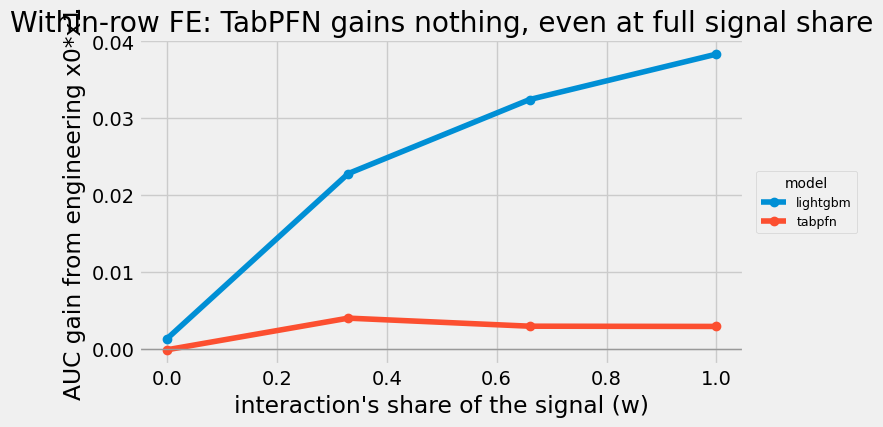

In [3]:
gain = g.pivot_table(index="w", columns="model", values="gain")
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for model in ["lightgbm", "tabpfn"]:
    ax.plot(gain.index, gain[model].values, marker="o", label=model)
ax.axhline(0, color="0.6", lw=1)
ax.set_xlabel("interaction's share of the signal (w)")
ax.set_ylabel("AUC gain from engineering x0*x1")
ax.set_title("Within-row FE: TabPFN gains nothing, even at full signal share")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), title="model", fontsize=9, title_fontsize=10)
fig.tight_layout()
plt.show()

Two things to read. **LightGBM's gain climbs** as the interaction matters more (it does not fully form
`x0*x1` among the noise features), reaching about +0.04 when the interaction is the whole target.
**TabPFN's gain stays flat near zero** at every share: it recovers the interaction from `x0` and `x1`
via attention regardless of how important it is. LogReg (in the table) gains hugely, up to +0.3, because
a linear model cannot form a product at all.

This is why within-row FE looks dead on real data: a hand-crafted ratio is only one weak contributor
there, and even at maximum importance it buys TabPFN nothing. The mechanism section makes that precise.

## Cross-row features

Now a feature that requires scanning rows. We build **entities**, each appearing several times. Each
entity has a latent quality; the target depends on it. A single row sees only a noisy `x`; the entity's
quality is the **average of `x` over the entity's rows**, a `groupby` mean.

The leakage boundary matters here. The engineered `entity_mean_x` is learned from the training rows and
then mapped into the test rows. If an entity is unseen in training, the helper uses the training global
mean. That is the real deployment shape of a cross-row aggregate.


In [4]:
def make_cross_row(n_entities, rows_per, x_noise=2.0, seed=0):
    """Create repeated entities whose average `x` is predictive of the target."""
    rng = np.random.RandomState(seed)

    entity_quality = rng.normal(size=n_entities)
    entity = np.repeat(np.arange(n_entities), rows_per)
    rng.shuffle(entity)

    x = entity_quality[entity] + rng.normal(0, x_noise, len(entity))
    y = (rng.random(len(entity)) < sigmoid(2.0 * entity_quality[entity])).astype(int)

    df = pd.DataFrame({"x": x, "entity": entity.astype(str)})
    for noise_index in range(3):
        df[f"z{noise_index}"] = rng.normal(size=len(entity))

    return df, y


def add_entity_mean(train, test):
    """Add a train-only group mean of `x` for each entity."""
    entity_mean = train.groupby("entity")["x"].mean()
    global_mean = float(train["x"].mean())

    train_with_feature = train.copy()
    test_with_feature = test.copy()

    train_with_feature["entity_mean_x"] = (
        train["entity"].map(entity_mean).fillna(global_mean).values
    )
    test_with_feature["entity_mean_x"] = (
        test["entity"].map(entity_mean).fillna(global_mean).values
    )

    return train_with_feature, test_with_feature


TOTAL_ROWS = 6000
ROWS_PER_ENTITY = [5, 20, 50]
SEEDS = [0, 1, 2]
MODELS = ["tabpfn", "lightgbm", "catboost"]

rows = []
for rows_per in tqdm(ROWS_PER_ENTITY, desc="rows per entity"):
    n_entities = TOTAL_ROWS // rows_per

    for seed in SEEDS:
        df, y = make_cross_row(n_entities, rows_per, seed=seed)
        split_at = len(y) // 2

        train = df.iloc[:split_at].reset_index(drop=True)
        test = df.iloc[split_at:].reset_index(drop=True)
        y_train = y[:split_at]
        y_test = y[split_at:]

        train_with_feature, test_with_feature = add_entity_mean(train, test)

        for model_name in MODELS:
            auc_without = score(
                model_name,
                train,
                y_train,
                test,
                y_test,
                seed,
                cat_cols=["entity"],
            )
            auc_with_feature = score(
                model_name,
                train_with_feature,
                y_train,
                test_with_feature,
                y_test,
                seed,
                cat_cols=["entity"],
            )
            rows.append({
                "rows_per": rows_per,
                "n_entities": n_entities,
                "seed": seed,
                "model": model_name,
                "gain": auc_with_feature - auc_without,
            })

cross = pd.DataFrame(rows)
print("AUC gain from adding entity_mean_x, by model and rows-per-entity:")
cross_gain_table = cross.pivot_table(index="rows_per", columns="model", values="gain")
printdf(cross_gain_table[["tabpfn", "lightgbm", "catboost"]].round(4))


rows per entity:   0%|                                              | 0/3 [00:00<?, ?it/s]

rows per entity:  33%|████████████▋                         | 1/3 [00:35<01:10, 35.35s/it]

rows per entity:  67%|█████████████████████████▎            | 2/3 [01:07<00:33, 33.25s/it]

rows per entity: 100%|██████████████████████████████████████| 3/3 [01:38<00:00, 32.28s/it]

rows per entity: 100%|██████████████████████████████████████| 3/3 [01:38<00:00, 32.76s/it]

AUC gain from adding entity_mean_x, by model and rows-per-entity:
+------------+----------+------------+------------+
|   rows_per |   tabpfn |   lightgbm |   catboost |
|------------+----------+------------+------------|
|          5 |   0.045  |     0.0679 |    -0.0038 |
|         20 |   0.1489 |     0.0736 |     0.0015 |
|         50 |   0.0035 |     0.0039 |     0.0016 |
+------------+----------+------------+------------+


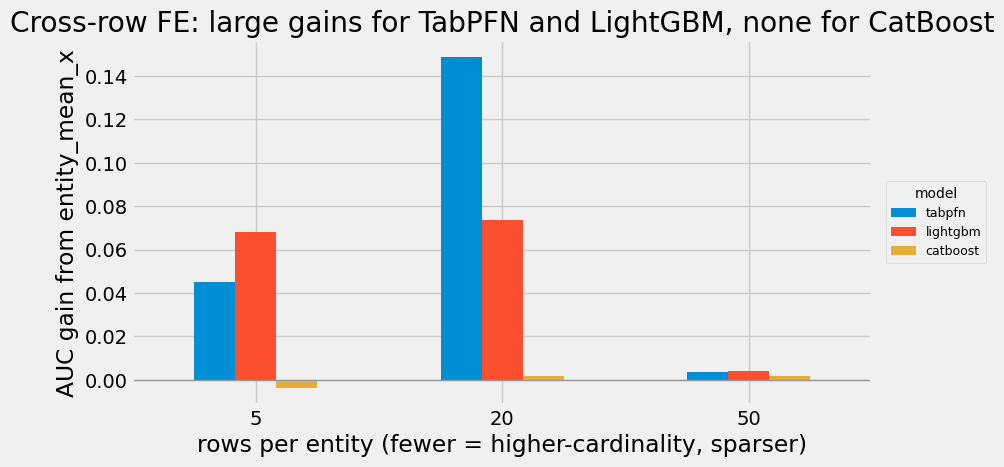

In [5]:
piv = cross.pivot_table(index="rows_per", columns="model", values="gain")[["tabpfn", "lightgbm", "catboost"]]
ax = piv.plot(kind="bar", figsize=(8.5, 4.5))
ax.axhline(0, color="0.6", lw=1)
ax.set_xlabel("rows per entity (fewer = higher-cardinality, sparser)")
ax.set_ylabel("AUC gain from entity_mean_x")
ax.set_title("Cross-row FE: large gains for TabPFN and LightGBM, none for CatBoost")
ax.legend(title="model", loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9, title_fontsize=10)
plt.xticks(rotation=0)
plt.show()

The opposite picture. When entities are **high-cardinality and sparsely observed**, the engineered
aggregate gives **large gains to both TabPFN and LightGBM**, because neither can pool an entity's rows
from a single observation. TabPFN's gain **peaks at about +0.15** in the moderate-cardinality regime (20
rows per entity), well above LightGBM; at the most extreme sparsity (5 rows per entity, 1,200 entities)
the two are comparable. The gain **vanishes when entities are well sampled** (50 rows each, only 120
entities): there both models recover the entity effect from the id itself, so the aggregate is redundant.

And **CatBoost gains nothing throughout**, because its native ordered target statistics already encode the
entity from its id, the same shortcut that made CatBoost special in the categoricals chapter, and the one
shortcut TabPFN lacks. So the cross-row gain is real, conditional on the aggregate carrying signal the id
alone does not.

## Real data check

Synthetic constructions can be engineered to make a point, so here is the real version. Amazon Employee
Access is nine high-cardinality id columns (RESOURCE has ~7,500 values) and a binary approval target.
This is the kind of table where old Kaggle feature engineering often starts with counts: "how common is
this id?" and "how often do these two ids appear together?"

Those counts are pure cross-row features. We add single-column frequency counts and a small set of
combination counts, computed from the training rows only, and measure the gain per model.


In [6]:
amazon = fetch_openml(data_id=4135, as_frame=True)
Xa = amazon.data.copy()
ya = amazon.target.astype(int).values

id_cols = list(Xa.columns)
combo_pairs = [
    ("RESOURCE", "MGR_ID"),
    ("RESOURCE", "ROLE_DEPTNAME"),
    ("MGR_ID", "ROLE_DEPTNAME"),
    ("RESOURCE", "ROLE_FAMILY"),
    ("ROLE_DEPTNAME", "ROLE_TITLE"),
]


def add_counts(train, test, include_combo_counts=False):
    """Add train-only frequency counts for ids and selected id pairs."""
    train_with_counts = train.copy()
    test_with_counts = test.copy()

    for column in id_cols:
        train_counts = train[column].value_counts()
        new_column = f"{column}_freq"

        train_with_counts[new_column] = (
            train[column].map(train_counts).fillna(0).astype(float).values
        )
        test_with_counts[new_column] = (
            test[column].map(train_counts).fillna(0).astype(float).values
        )

    if include_combo_counts:
        for first, second in combo_pairs:
            train_key = train[first].astype(str) + "_" + train[second].astype(str)
            test_key = test[first].astype(str) + "_" + test[second].astype(str)
            train_counts = train_key.value_counts()
            new_column = f"{first}_{second}_cnt"

            train_with_counts[new_column] = (
                train_key.map(train_counts).fillna(0).astype(float).values
            )
            test_with_counts[new_column] = (
                test_key.map(train_counts).fillna(0).astype(float).values
            )

    return train_with_counts, test_with_counts


rows = []
for seed in tqdm([0, 1, 2], desc="seed"):
    rng = np.random.RandomState(seed)
    sampled_rows = rng.permutation(len(Xa))[:16000]
    split_at = 8000

    train = Xa.iloc[sampled_rows[:split_at]].reset_index(drop=True)
    test = Xa.iloc[sampled_rows[split_at:]].reset_index(drop=True)
    y_train = ya[sampled_rows[:split_at]]
    y_test = ya[sampled_rows[split_at:]]

    train_with_freq, test_with_freq = add_counts(train, test, include_combo_counts=False)
    train_with_combos, test_with_combos = add_counts(train, test, include_combo_counts=True)

    for model_name in ["tabpfn", "lightgbm", "catboost"]:
        rows.append({
            "seed": seed,
            "model": model_name,
            "base": score(model_name, train, y_train, test, y_test, seed, cat_cols=id_cols),
            "freq": score(
                model_name,
                train_with_freq,
                y_train,
                test_with_freq,
                y_test,
                seed,
                cat_cols=id_cols,
            ),
            "freq_combo": score(
                model_name,
                train_with_combos,
                y_train,
                test_with_combos,
                y_test,
                seed,
                cat_cols=id_cols,
            ),
        })

amz = pd.DataFrame(rows).groupby("model")[["base", "freq", "freq_combo"]].mean()
amz["gain_freq"] = amz["freq"] - amz["base"]
amz["gain_combo"] = amz["freq_combo"] - amz["base"]

print("Amazon Employee Access: AUC by feature set, and gains, per model:")
printdf(amz.loc[["tabpfn", "lightgbm", "catboost"]].round(4))


seed:   0%|                                                         | 0/3 [00:00<?, ?it/s]

seed:  33%|████████████████▎                                | 1/3 [00:52<01:45, 52.54s/it]

seed:  67%|████████████████████████████████▋                | 2/3 [01:44<00:52, 52.18s/it]

seed: 100%|█████████████████████████████████████████████████| 3/3 [02:37<00:00, 52.57s/it]

seed: 100%|█████████████████████████████████████████████████| 3/3 [02:37<00:00, 52.50s/it]

Amazon Employee Access: AUC by feature set, and gains, per model:
+----------+--------+--------+--------------+-------------+--------------+
| model    |   base |   freq |   freq_combo |   gain_freq |   gain_combo |
|----------+--------+--------+--------------+-------------+--------------|
| tabpfn   | 0.788  | 0.8018 |       0.8038 |      0.0138 |       0.0159 |
| lightgbm | 0.7835 | 0.8019 |       0.8073 |      0.0185 |       0.0239 |
| catboost | 0.8203 | 0.8134 |       0.815  |     -0.0069 |      -0.0054 |
+----------+--------+--------+--------------+-------------+--------------+


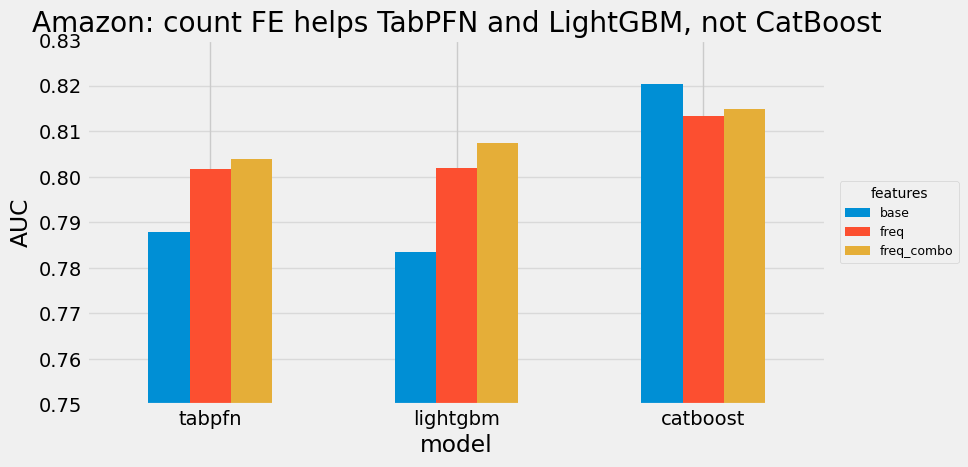

In [7]:
bars = amz.loc[["tabpfn", "lightgbm", "catboost"], ["base", "freq", "freq_combo"]]
ax = bars.plot(kind="bar", figsize=(8.5, 4.5))
ax.set_ylim(0.75, 0.83)
ax.set_ylabel("AUC")
ax.set_axisbelow(True); ax.grid(axis="y", alpha=0.6)
ax.set_title("Amazon: count FE helps TabPFN and LightGBM, not CatBoost")
ax.legend(title="features", loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9, title_fontsize=10)
plt.xticks(rotation=0)
plt.show()

The synthetic split holds on real data. **TabPFN gains about +0.014 from frequency and +0.016 from
combination counts**, real lift from features it cannot compute per row. **LightGBM gains the most**
(about +0.024). And **CatBoost loses a little**, because its native target statistics already encode the
ids, so raw counts are redundant noise. The same three-way pattern as the synthetic entity test.

## Why the split holds

Every result above is the same quantity: **the gain from an engineered feature equals its incremental
predictiveness given what the model already recovers from the raw inputs.** A feature helps only when it
carries signal the model cannot reconstruct on its own.

- **Within-row** features (products, ratios): TabPFN reconstructs them with cross-feature attention, so
  the incremental term is ~0 for it at any importance. A linear model reconstructs nothing, so it is
  FE-hungry. Trees sit in between.
- **Cross-row** features (aggregates): TabPFN cannot reconstruct them per prediction, so the incremental
  term is large, unless the cross-row effect is already learnable from a low-cardinality, well-sampled id
  (then it reconstructs it and the term collapses), or a model has a native shortcut (CatBoost's ordered
  target statistics).

We can see the "incremental predictiveness" directly on a real within-row ratio. On Taiwan credit, the
classic utilization ratio is bill amount divided by credit limit:


In [8]:
credit = fetch_openml(name="default-of-credit-card-clients", as_frame=True)
Xc = credit.data.astype(float).reset_index(drop=True)

if str(credit.target.dtype) in ("object", "category"):
    yc = credit.target.astype(str).isin(["1", "yes"]).astype(int).values
else:
    yc = credit.target.astype(int).values

utilization = (Xc["x12"] / Xc["x1"]).rename("utilization")

rng = np.random.RandomState(0)
n = 12000
sampled_rows = rng.permutation(len(Xc))[:n]
split_at = n // 2

Xs = Xc.iloc[sampled_rows].reset_index(drop=True)
ys = yc[sampled_rows]
u = utilization.iloc[sampled_rows].reset_index(drop=True)


def lgbm_auc(features):
    """Fit LightGBM on the first half and score AUC on the second half."""
    model = LGBMClassifier(verbose=-1)
    model.fit(features.iloc[:split_at], ys[:split_at])
    probabilities = model.predict_proba(features.iloc[split_at:])[:, 1]
    return roc_auc_score(ys[split_at:], probabilities)


feature_sets = {
    "utilization ALONE": u.to_frame(),
    "its components {limit, bill}": Xs[["x1", "x12"]],
    "components + utilization": pd.concat([Xs[["x1", "x12"]], u], axis=1),
    "all 23 raw columns": Xs,
    "all 23 + utilization": pd.concat([Xs, u], axis=1),
}

print("Taiwan credit, LightGBM AUC by feature set (the incremental value of the ratio):")
for name, features in feature_sets.items():
    print(f"  {name:32} {lgbm_auc(features):.4f}")


Taiwan credit, LightGBM AUC by feature set (the incremental value of the ratio):
  utilization ALONE                0.5686
  its components {limit, bill}     0.6147


  components + utilization         0.6164
  all 23 raw columns               0.7618


  all 23 + utilization             0.7687


The ratio scores only 0.569 alone, adds about +0.002 over its own components (the model recovers it from
limit and bill), and about +0.007 against the full 0.76 model. Tiny incremental signal, so it helps no
model much, TabPFN included. A cross-row count on Amazon, by contrast, carries signal no single row holds,
so it helps the models that cannot compute it.

This is also the old Kaggle lesson. In [Will Koehrsen's Home Credit manual feature-engineering notebook](https://www.kaggle.com/code/willkoehrsen/introduction-to-manual-feature-engineering),
the central move is aggregating auxiliary tables back to each client. In [Chris Deotte's Santander notebook](https://www.kaggle.com/code/cdeotte/200-magical-models-santander-0-920),
the "magic" feature is a per-value frequency count. In his [IEEE-CIS fraud notebook](https://www.kaggle.com/code/cdeotte/xgb-fraud-with-magic-0-9600),
UID and count-style features are part of the 0.96 XGBoost story. Those are different competitions, but the
same shape: useful information is spread across rows, then summarized into a feature a row-level model can
consume.

TabPFN benefits from precisely this family, and often more than a tuned GBM.


### Honest limits

- The dramatic synthetic gains (entity aggregates up to +0.16) need the aggregate to carry most of the
  signal; on real data with strong existing features the gains are smaller (Amazon +0.016) but in the same
  direction.
- The cross-row gain is **conditional**: it requires high-cardinality, sparsely-observed entities. Well
  sampled, low-cardinality ids are recovered from the id alone and the aggregate adds nothing.
- CatBoost is the standing exception via native target statistics.
- AutoGluon and TabPrep are useful references, but they should not be load-bearing prerequisites for this
  chapter. The reader should understand the result from the within-row versus cross-row split alone.
- All models run on default hyperparameters.


## Takeaways

For TabPFN the feature-engineering question is not **whether**, it is **what**:

- **Within-row** features (interactions, ratios, polynomials) are redundant: attention forms them, even
  when they are the entire signal. Stop reflexively adding products and ratios.
- **Cross-row** features (group-by aggregates, counts, frequency and target encoding, entity statistics)
  are where engineering earns its keep, because TabPFN cannot compute them per prediction. This is the
  feature-engineering family behind many strong Kaggle notebooks.
- The single rule: engineer the features your model cannot reconstruct from your data. For TabPFN, that
  usually means cross-row, not within-row.
